# Day 4 – ML Fundamentals + Data Preprocessing
### 20-Day ML Revision Planner | Phase: Core ML

**Topics covered:**
1. AI vs ML vs DL
2. Supervised, Unsupervised, and Reinforcement Learning
3. Features, Labels, Training, Validation, and Testing
4. Generalization (Overfitting vs Underfitting)
5. Missing Values & Duplicates
6. Outliers
7. Categorical Encoding
8. Scaling (Normalization vs Standardization)
9. Feature Engineering & Feature Selection (intro)
10. Coding: `Pipeline` + `ColumnTransformer` — a Complete Train/Test Pipeline
11. Interview Questions
12. Active Recall Checklist

**Revision rule:** Learn → Close Notes → Recall → Code → Debug → Explain → Interview Question.

---


In [1]:
# Setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, OrdinalEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

np.set_printoptions(precision=4, suppress=True)
pd.set_option('display.precision', 4)
np.random.seed(42)
print("All imports successful.")


All imports successful.


## 1. AI vs ML vs DL

### What?
- **Artificial Intelligence (AI)**: the broad field of building systems that perform tasks requiring human-like intelligence (reasoning, perception, decision-making). Includes rule-based systems, search algorithms, ML, and more.
- **Machine Learning (ML)**: a subset of AI where systems **learn patterns from data** rather than being explicitly programmed with rules.
- **Deep Learning (DL)**: a subset of ML that uses **multi-layered neural networks** to automatically learn hierarchical feature representations, especially powerful for unstructured data (images, text, audio).

$$\text{AI} \supset \text{ML} \supset \text{DL}$$

### Why?
Interviewers frequently probe this distinction to check conceptual clarity — confusing these terms is a common red flag.

### How to tell them apart in practice?
| | Example |
|---|---|
| AI (non-ML) | A chess engine using rule-based minimax search |
| ML (non-DL) | Logistic Regression predicting loan default from tabular features |
| DL | A CNN classifying images of cats vs dogs |


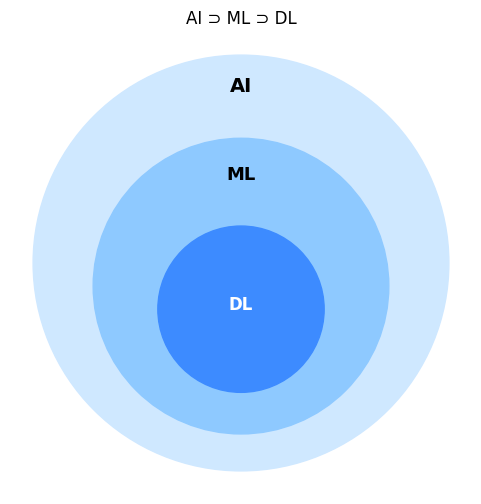

In [2]:
# A simple visual: nested circles showing AI ⊃ ML ⊃ DL
fig, ax = plt.subplots(figsize=(6, 6))
circle_ai = plt.Circle((0.5, 0.5), 0.45, color='#cfe8ff', label='AI')
circle_ml = plt.Circle((0.5, 0.45), 0.32, color='#8ec9ff', label='ML')
circle_dl = plt.Circle((0.5, 0.4), 0.18, color='#3d8bff', label='DL')

ax.add_patch(circle_ai)
ax.add_patch(circle_ml)
ax.add_patch(circle_dl)

ax.text(0.5, 0.87, "AI", ha='center', fontsize=14, fontweight='bold')
ax.text(0.5, 0.68, "ML", ha='center', fontsize=13, fontweight='bold')
ax.text(0.5, 0.4, "DL", ha='center', fontsize=12, fontweight='bold', color='white')

ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_aspect('equal'); ax.axis('off')
ax.set_title("AI ⊃ ML ⊃ DL")
plt.show()


## 2. Supervised, Unsupervised, and Reinforcement Learning

### What?
- **Supervised Learning**: learn a mapping from inputs to **known** outputs (labels). E.g., regression, classification.
- **Unsupervised Learning**: find structure in data **without** labels. E.g., clustering, dimensionality reduction.
- **Reinforcement Learning (RL)**: an **agent** learns to make decisions by taking actions in an **environment** to maximize cumulative **reward**, via trial and error.

### Why?
The type of learning problem determines which algorithms and evaluation metrics are appropriate — this is usually the very first question to ask when framing an ML problem.

### How to distinguish?
| Type | Data | Goal | Example Algorithms |
|---|---|---|---|
| Supervised | Labeled (X, y) | Predict y for new X | Linear/Logistic Regression, Decision Trees, SVM |
| Unsupervised | Unlabeled (X only) | Discover structure | K-Means, PCA, DBSCAN |
| Reinforcement | State, action, reward | Maximize long-term reward | Q-Learning, Policy Gradient |


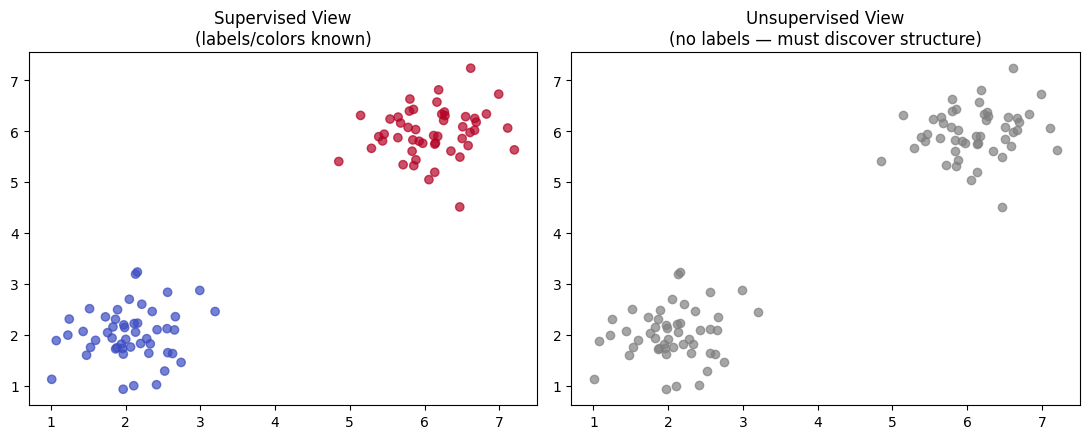

In [3]:
# Toy illustration: same data, viewed as supervised (with labels) vs unsupervised (without)
np.random.seed(10)
cluster1 = np.random.normal([2, 2], 0.5, (50, 2))
cluster2 = np.random.normal([6, 6], 0.5, (50, 2))
X_toy = np.vstack([cluster1, cluster2])
y_toy = np.array([0]*50 + [1]*50)   # labels available in supervised setting

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

axes[0].scatter(X_toy[:, 0], X_toy[:, 1], c=y_toy, cmap='coolwarm', alpha=0.7)
axes[0].set_title("Supervised View\n(labels/colors known)")

axes[1].scatter(X_toy[:, 0], X_toy[:, 1], c='gray', alpha=0.7)
axes[1].set_title("Unsupervised View\n(no labels — must discover structure)")

plt.tight_layout()
plt.show()


## 3. Features, Labels, Training, Validation, and Testing

### What?
- **Features (X)**: the input variables/attributes describing each sample.
- **Label / Target (y)**: the value we're trying to predict (only exists in supervised learning).
- **Training set**: data used to **fit** the model's parameters.
- **Validation set**: data used to **tune hyperparameters** and make model-selection decisions, without touching the test set.
- **Test set**: held-out data used **only once**, at the end, to estimate how the model will perform on truly unseen data.

### Why?
Using the same data for training and evaluation gives an overly optimistic (and useless) estimate of real-world performance. Splitting data properly is what allows us to detect overfitting.

### How?
A common split: 60% train / 20% validation / 20% test, or use train/test + k-fold cross-validation on the training set (covered in depth on Day 10).

⚠️ **Golden rule**: Never let information from the test set leak into training (e.g., don't fit scalers/imputers on the full dataset before splitting — more on this below).


In [4]:
# Demonstrate train / validation / test split
np.random.seed(11)
n = 1000
X_demo = np.random.rand(n, 3)
y_demo = (X_demo[:, 0] + X_demo[:, 1] > 1).astype(int)

X_train, X_temp, y_train, y_temp = train_test_split(X_demo, y_demo, test_size=0.4, random_state=42, stratify=y_demo)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print(f"Train set: {X_train.shape[0]} samples ({X_train.shape[0]/n:.0%})")
print(f"Validation set: {X_val.shape[0]} samples ({X_val.shape[0]/n:.0%})")
print(f"Test set: {X_test.shape[0]} samples ({X_test.shape[0]/n:.0%})")
print("\nClass balance is preserved across splits via `stratify=y`:")
for name, y_split in [("Train", y_train), ("Val", y_val), ("Test", y_test)]:
    print(f"  {name}: class 0 = {(y_split==0).mean():.2%}, class 1 = {(y_split==1).mean():.2%}")


Train set: 600 samples (60%)
Validation set: 200 samples (20%)
Test set: 200 samples (20%)

Class balance is preserved across splits via `stratify=y`:
  Train: class 0 = 48.83%, class 1 = 51.17%
  Val: class 0 = 49.00%, class 1 = 51.00%
  Test: class 0 = 49.00%, class 1 = 51.00%


## 4. Generalization

### What?
**Generalization** is a model's ability to perform well on **new, unseen data**, not just the data it was trained on.
- **Overfitting**: model learns the training data *too well*, including its noise — low training error, high test error.
- **Underfitting**: model is too simple to capture the underlying pattern — high error on both training and test data.

### Why?
The entire goal of ML is generalization, not memorization. Every technique in this planner — regularization, cross-validation, proper preprocessing, ensembling — ultimately serves this goal.

### How to detect it?
Compare training performance vs validation/test performance:
- Train error low, validation error high → **overfitting** (high variance).
- Train error high, validation error high → **underfitting** (high bias).
- Train error low, validation error low (and close together) → **good generalization**.


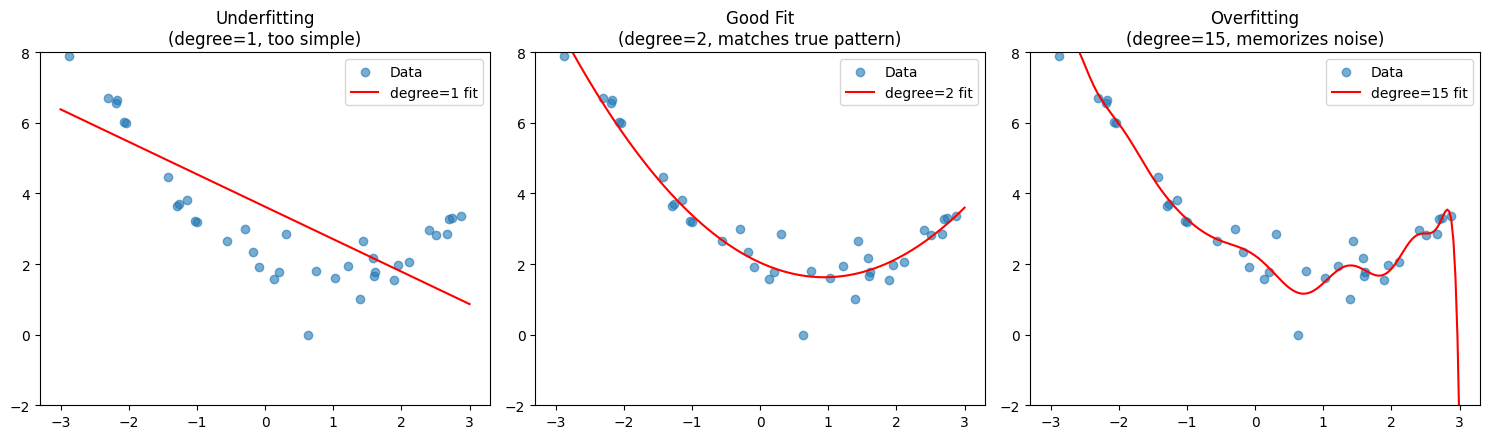

In [5]:
# Visualize underfitting vs good fit vs overfitting using polynomial regression
np.random.seed(12)
X_poly = np.sort(np.random.rand(40, 1) * 6 - 3, axis=0)
y_poly = 0.5 * X_poly[:, 0]**2 - X_poly[:, 0] + 2 + np.random.normal(0, 0.5, 40)

from numpy.polynomial.polynomial import polyfit, polyval

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
degrees = [1, 2, 15]
titles = ["Underfitting\n(degree=1, too simple)", "Good Fit\n(degree=2, matches true pattern)", "Overfitting\n(degree=15, memorizes noise)"]

x_smooth = np.linspace(-3, 3, 200)
for ax, deg, title in zip(axes, degrees, titles):
    coeffs = polyfit(X_poly[:, 0], y_poly, deg)
    y_smooth = polyval(x_smooth, coeffs)
    ax.scatter(X_poly, y_poly, alpha=0.6, label="Data")
    ax.plot(x_smooth, y_smooth, color='red', label=f"degree={deg} fit")
    ax.set_ylim(-2, 8)
    ax.set_title(title)
    ax.legend()

plt.tight_layout()
plt.show()


## 5. Missing Values & Duplicates

### What?
- **Missing values**: entries with no recorded value (NaN, null, empty string).
- **Duplicates**: identical (or near-identical) rows appearing more than once.

### Why?
- Most ML algorithms **cannot handle NaNs** directly and will error out or silently produce garbage results.
- Duplicates can **bias training** (over-representing certain samples) and inflate performance metrics if duplicates leak across train/test splits.

### How?
Common strategies for missing values:
- **Drop** rows/columns (only if missingness is small and random).
- **Impute** with mean/median (numerical) or mode (categorical).
- **Impute** with a model-based approach (e.g., KNN imputation) for more accuracy.
- Add a **"was_missing" indicator column** if missingness itself might be informative.

For duplicates: identify and drop with `df.duplicated()` / `df.drop_duplicates()`.


In [6]:
# Build a messy toy dataset to practice preprocessing (used throughout the rest of the notebook)
np.random.seed(13)
n_samples = 300

df = pd.DataFrame({
    'age': np.random.randint(18, 70, n_samples).astype(float),
    'income': np.random.normal(50000, 15000, n_samples),
    'city': np.random.choice(['Delhi', 'Mumbai', 'Bangalore', 'Chennai'], n_samples),
    'education': np.random.choice(['High School', 'Bachelors', 'Masters', 'PhD'], n_samples),
    'purchased': np.random.choice([0, 1], n_samples, p=[0.6, 0.4])
})

# Inject missing values
missing_idx_age = np.random.choice(n_samples, 20, replace=False)
missing_idx_income = np.random.choice(n_samples, 15, replace=False)
missing_idx_city = np.random.choice(n_samples, 10, replace=False)
df.loc[missing_idx_age, 'age'] = np.nan
df.loc[missing_idx_income, 'income'] = np.nan
df.loc[missing_idx_city, 'city'] = np.nan

# Inject some outliers
df.loc[np.random.choice(n_samples, 5, replace=False), 'income'] = df['income'].max() * 5

# Inject duplicate rows
df = pd.concat([df, df.iloc[:8]], ignore_index=True)

print("Dataset shape:", df.shape)
df.head(10)


Dataset shape: (308, 5)


,age,income,city,education,purchased
0,36.0,23644.4717,Delhi,PhD,0
1,66.0,45079.3610,Mumbai,Masters,0
2,28.0,40331.3325,Delhi,PhD,0
3,34.0,35098.2756,Chennai,Bachelors,1
4,56.0,51414.5904,Mumbai,Bachelors,0
5,52.0,51564.2401,Bangalore,Bachelors,0
6,43.0,32590.5480,Chennai,PhD,1
7,NaN,65500.2309,Chennai,PhD,0
8,53.0,49303.5973,Bangalore,High School,0
9,NaN,38310.2966,Mumbai,High School,1


Missing values per column:
age          21
income       15
city         10
education     0
purchased     0
dtype: int64

Total missing values: 46
Percentage of rows with at least one missing value: 13.96%


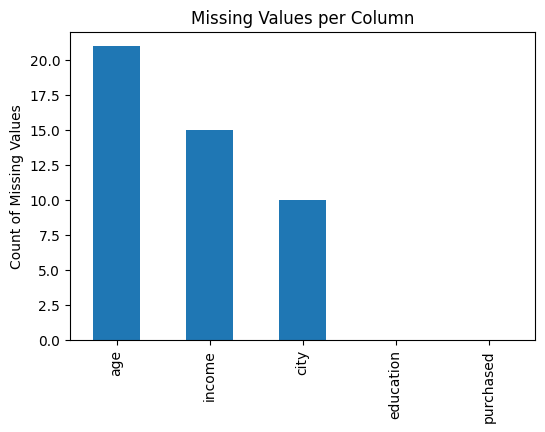

In [7]:
# Inspect missing values
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nTotal missing values: {df.isnull().sum().sum()}")
print(f"Percentage of rows with at least one missing value: {df.isnull().any(axis=1).mean():.2%}")

plt.figure(figsize=(6, 4))
df.isnull().sum().plot(kind='bar')
plt.title("Missing Values per Column")
plt.ylabel("Count of Missing Values")
plt.show()


In [8]:
# Detect and remove duplicates
n_duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {n_duplicates}")

df_clean = df.drop_duplicates().reset_index(drop=True)
print(f"Shape before removing duplicates: {df.shape}")
print(f"Shape after removing duplicates:  {df_clean.shape}")


Number of duplicate rows: 8
Shape before removing duplicates: (308, 5)
Shape after removing duplicates:  (300, 5)


## 6. Outliers

### What?
**Outliers** are data points that deviate significantly from the rest of the data. They may be genuine rare events or data-entry errors.

### Why?
Outliers can **distort statistics** (mean, std), **skew model training** (especially for linear models and distance-based algorithms), and **degrade performance**. But sometimes outliers are the *most important* points (e.g., fraud detection) — so context matters before removing them.

### How?
Two common detection methods:
- **Z-score method**: flag points with $|z| > 3$ (from Day 3).
- **IQR (Interquartile Range) method**: flag points outside $[Q1 - 1.5 \times IQR, \; Q3 + 1.5 \times IQR]$.


IQR bounds for 'income': [9362, 90086]
Number of outliers detected: 7


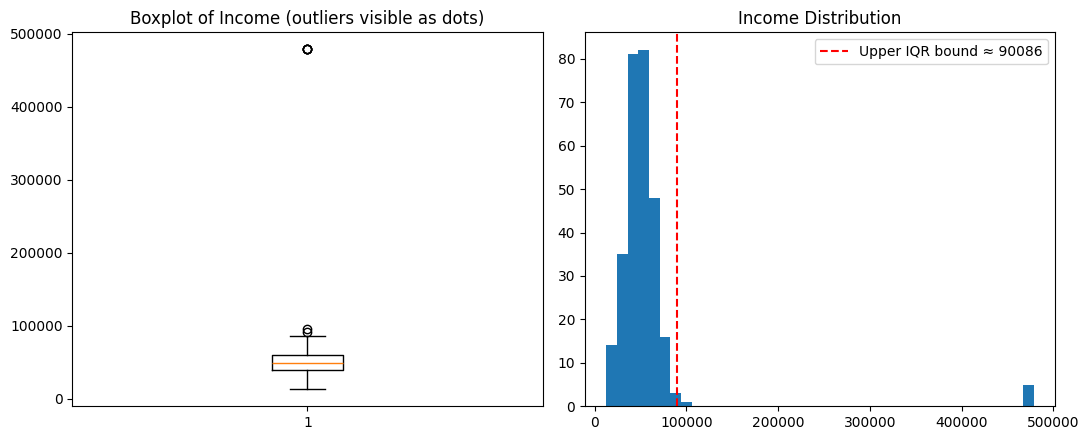

In [9]:
# Outlier detection using the IQR method
def detect_outliers_iqr(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return (series < lower_bound) | (series > upper_bound), lower_bound, upper_bound

outlier_mask, lower, upper = detect_outliers_iqr(df_clean['income'].dropna())
print(f"IQR bounds for 'income': [{lower:.0f}, {upper:.0f}]")
print(f"Number of outliers detected: {outlier_mask.sum()}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].boxplot(df_clean['income'].dropna())
axes[0].set_title("Boxplot of Income (outliers visible as dots)")
axes[1].hist(df_clean['income'].dropna(), bins=40)
axes[1].axvline(upper, color='red', linestyle='--', label=f'Upper IQR bound ≈ {upper:.0f}')
axes[1].set_title("Income Distribution")
axes[1].legend()
plt.tight_layout()
plt.show()


## 7. Categorical Encoding

### What?
ML models require **numerical input**, so categorical (text/label) features must be converted to numbers.
- **One-Hot Encoding**: creates a binary column per category. Best for **nominal** data (no inherent order), e.g., city names.
- **Ordinal/Label Encoding**: maps categories to integers based on order. Best for **ordinal** data (has inherent order), e.g., education level (`High School` < `Bachelors` < `Masters` < `PhD`).

### Why?
Using the wrong encoding introduces a false sense of order/magnitude. E.g., label-encoding `city` as `Delhi=0, Mumbai=1, Bangalore=2` would falsely imply `Bangalore > Mumbai > Delhi`, which a model might exploit nonsensically.

### How?
| Encoding | When to use | Risk |
|---|---|---|
| One-Hot | Nominal categories, low-to-moderate cardinality | High cardinality → many columns ("curse of dimensionality") |
| Ordinal | Categories with a natural order | Wrong if applied to nominal data (implies false ranking) |


In [10]:
# One-Hot Encoding demo (for nominal 'city')
city_filled = df_clean['city'].fillna('Unknown')
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
city_encoded = ohe.fit_transform(city_filled.values.reshape(-1, 1))
city_encoded_df = pd.DataFrame(city_encoded, columns=ohe.get_feature_names_out(['city']))
print("One-Hot Encoded 'city' (first 5 rows):")
print(city_encoded_df.head())

# Ordinal Encoding demo (for ordinal 'education')
education_order = [['High School', 'Bachelors', 'Masters', 'PhD']]
ordinal_enc = OrdinalEncoder(categories=education_order)
education_encoded = ordinal_enc.fit_transform(df_clean[['education']])
print("\nOrdinal Encoded 'education' (first 10 rows):")
comparison = pd.DataFrame({'education': df_clean['education'].head(10).values,
                            'encoded': education_encoded[:10].ravel()})
print(comparison)
print("\n--> Notice PhD=3 > Masters=2 > Bachelors=1 > High School=0, preserving true order.")


One-Hot Encoded 'city' (first 5 rows):
   city_Bangalore  city_Chennai  city_Delhi  city_Mumbai  city_Unknown
0             0.0           0.0         1.0          0.0           0.0
1             0.0           0.0         0.0          1.0           0.0
2             0.0           0.0         1.0          0.0           0.0
3             0.0           1.0         0.0          0.0           0.0
4             0.0           0.0         0.0          1.0           0.0

Ordinal Encoded 'education' (first 10 rows):
     education  encoded
0          PhD      3.0
1      Masters      2.0
2          PhD      3.0
3    Bachelors      1.0
4    Bachelors      1.0
5    Bachelors      1.0
6          PhD      3.0
7          PhD      3.0
8  High School      0.0
9  High School      0.0

--> Notice PhD=3 > Masters=2 > Bachelors=1 > High School=0, preserving true order.


## 8. Scaling: Normalization vs Standardization

### What?
- **Standardization (Z-score scaling)**: rescales features to have mean 0 and standard deviation 1.
  $$z = \frac{x - \mu}{\sigma}$$
- **Normalization (Min-Max scaling)**: rescales features to a fixed range, typically [0, 1].
  $$x_{norm} = \frac{x - x_{min}}{x_{max} - x_{min}}$$

### Why?
- **Distance-based models** (KNN, K-Means, SVM) and **gradient-based models** (linear/logistic regression, neural networks) are sensitive to feature scale — a feature ranging in the thousands (income) would dominate one ranging 0–1 (a ratio), even if the smaller-range feature is more predictive.
- **Tree-based models** (Decision Trees, Random Forest, Gradient Boosting) are generally **scale-invariant** and don't require this step.

### How to choose?
| Method | Best for | Sensitive to outliers? |
|---|---|---|
| Standardization | Data roughly Gaussian; most general-purpose default | Less sensitive |
| Min-Max Normalization | Bounded ranges needed (e.g., neural net inputs, image pixels) | Very sensitive (outliers distort min/max) |

⚠️ **Critical rule**: Always `fit` the scaler on the **training set only**, then `transform` both train and test sets with those fitted parameters — fitting on the full dataset (including test data) is a form of **data leakage**.


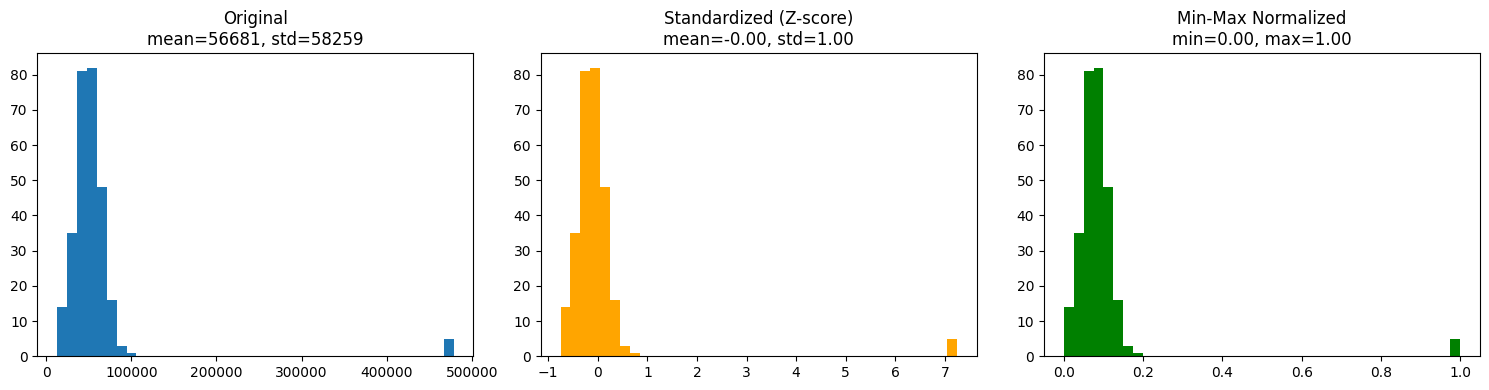

--> Standardization centers data around 0 with unit variance.
--> Min-Max squashes data into [0, 1] but is heavily skewed by the outliers we injected earlier.


In [11]:
# Compare Standardization vs Min-Max Normalization
sample_col = df_clean[['income']].dropna()

scaler_std = StandardScaler()
scaler_minmax = MinMaxScaler()

standardized = scaler_std.fit_transform(sample_col)
normalized = scaler_minmax.fit_transform(sample_col)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(sample_col.values, bins=40)
axes[0].set_title(f"Original\nmean={sample_col.values.mean():.0f}, std={sample_col.values.std():.0f}")
axes[1].hist(standardized, bins=40, color='orange')
axes[1].set_title(f"Standardized (Z-score)\nmean={standardized.mean():.2f}, std={standardized.std():.2f}")
axes[2].hist(normalized, bins=40, color='green')
axes[2].set_title(f"Min-Max Normalized\nmin={normalized.min():.2f}, max={normalized.max():.2f}")
plt.tight_layout()
plt.show()

print("--> Standardization centers data around 0 with unit variance.")
print("--> Min-Max squashes data into [0, 1] but is heavily skewed by the outliers we injected earlier.")


## 9. Feature Engineering & Feature Selection (Introduction)

### What?
- **Feature engineering**: creating new, more informative features from existing raw data (e.g., extracting "day of week" from a date, or "income per family member").
- **Feature selection**: choosing the most relevant subset of features, discarding redundant or irrelevant ones.

### Why?
Good features often matter more than model choice — "garbage in, garbage out." These topics get a **full dedicated day (Day 13)** later in the plan; today we just need enough to build a preprocessing pipeline.

### How? (preview)
- Binning continuous variables (e.g., age → age groups).
- Creating interaction/ratio features.
- Dropping near-zero-variance or highly-correlated redundant features (uses correlation from Day 3, and rank/multicollinearity from Day 1).

We'll go deep into this on Day 13 — for now, focus on the mechanics of building a robust *preprocessing pipeline*, which is today's core coding deliverable.


## 10. Coding Practice — Building a Complete, Reusable Preprocessing Pipeline

**Goal:** Combine everything above (imputation, encoding, scaling) into a single scikit-learn `Pipeline` + `ColumnTransformer`, so that:
- Numerical and categorical columns are processed differently, automatically.
- The exact same transformations can be applied consistently to training and test data (no leakage, no manual re-coding).
- The whole pipeline can be reused on new incoming data with a single `.transform()` call.


In [12]:
# Step 1: Split into train/test BEFORE fitting any preprocessing (avoids data leakage)
X = df_clean.drop(columns=['purchased'])
y = df_clean['purchased']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
print("Train shape:", X_train.shape, "| Test shape:", X_test.shape)

numeric_features = ['age', 'income']
ordinal_features = ['education']
nominal_features = ['city']

print("\nNumeric features:", numeric_features)
print("Ordinal features:", ordinal_features)
print("Nominal features:", nominal_features)


Train shape: (225, 4) | Test shape: (75, 4)

Numeric features: ['age', 'income']
Ordinal features: ['education']
Nominal features: ['city']


In [13]:
# Step 2: Define per-column-type preprocessing pipelines

numeric_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),   # median is robust to the outliers we injected
    ('scaler', StandardScaler())
])

ordinal_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(categories=[['High School', 'Bachelors', 'Masters', 'PhD']]))
])

nominal_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# Step 3: Combine into a single ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_pipeline, numeric_features),
    ('ord', ordinal_pipeline, ordinal_features),
    ('nom', nominal_pipeline, nominal_features)
])

print("ColumnTransformer built with 3 branches: numeric, ordinal, nominal.")
preprocessor


ColumnTransformer built with 3 branches: numeric, ordinal, nominal.


,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('ord', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e

In [14]:
# Step 4: Fit the preprocessor on TRAINING data only, then transform both train and test
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)   # note: transform only, NOT fit_transform (no leakage!)

print("Processed training shape:", X_train_processed.shape)
print("Processed test shape:    ", X_test_processed.shape)

feature_names = preprocessor.get_feature_names_out()
print("\nFinal feature names after preprocessing:")
print(list(feature_names))


Processed training shape: (225, 8)
Processed test shape:     (75, 8)

Final feature names after preprocessing:
['num__age', 'num__income', 'ord__education', 'nom__city_Bangalore', 'nom__city_Chennai', 'nom__city_Delhi', 'nom__city_Mumbai', 'nom__city_Unknown']


In [15]:
# Step 5: Combine preprocessing + model into ONE end-to-end Pipeline
full_pipeline = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

full_pipeline.fit(X_train, y_train)
y_pred = full_pipeline.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Test accuracy: {accuracy:.2%}\n")
print(classification_report(y_test, y_pred))

print("--> The full pipeline handles raw messy data (with NaNs and mixed types) end-to-end:")
print("    raw X_test  --[preprocessing]-->  numeric matrix  --[classifier]-->  predictions")
print("    This single object can be saved (e.g., with pickle/joblib) and reused on new data.")


Test accuracy: 62.67%

              precision    recall  f1-score   support

           0       0.62      1.00      0.77        46
           1       1.00      0.03      0.07        29

    accuracy                           0.63        75
   macro avg       0.81      0.52      0.42        75
weighted avg       0.77      0.63      0.50        75

--> The full pipeline handles raw messy data (with NaNs and mixed types) end-to-end:
    raw X_test  --[preprocessing]-->  numeric matrix  --[classifier]-->  predictions
    This single object can be saved (e.g., with pickle/joblib) and reused on new data.


In [16]:
# Debug exercise: what happens if we forget to split before fitting the scaler? (data leakage demo)
scaler_leaky = StandardScaler()
scaler_leaky.fit(X[numeric_features].fillna(X[numeric_features].median()))  # fit on FULL dataset (wrong!)

scaler_correct = StandardScaler()
scaler_correct.fit(X_train[numeric_features].fillna(X_train[numeric_features].median()))  # fit on TRAIN only (correct)

print("Mean learned by scaler fit on FULL data (leaky):", scaler_leaky.mean_)
print("Mean learned by scaler fit on TRAIN only (correct):", scaler_correct.mean_)
print("\n--> The means differ slightly because the leaky scaler 'saw' the test set's distribution")
print("    during fitting. In small datasets or with distributional shift, this difference can")
print("    meaningfully bias evaluation metrics to look better than real-world performance.")


Mean learned by scaler fit on FULL data (leaky): [   45.22   56322.3897]
Mean learned by scaler fit on TRAIN only (correct): [   44.92   52854.1855]

--> The means differ slightly because the leaky scaler 'saw' the test set's distribution
    during fitting. In small datasets or with distributional shift, this difference can
    meaningfully bias evaluation metrics to look better than real-world performance.


## ML Connection Recap

| Concept | Why it matters in the ML workflow |
|---|---|
| Train/val/test split | Honest estimate of generalization performance |
| Missing value imputation | Most models can't handle NaN; median/mode is robust to skew/outliers |
| Outlier handling | Prevents distorted statistics and unstable model coefficients |
| Categorical encoding | Converts non-numeric data into a form models can use, without introducing false order |
| Scaling | Puts features on comparable scales for distance/gradient-based models |
| `Pipeline` + `ColumnTransformer` | Prevents data leakage, ensures reproducibility, enables clean deployment |


## 11. Interview Questions — Practice Aloud (Close Your Notes!)

1. **What's the difference between AI, ML, and DL?**
   *Hint: nested subsets — AI ⊃ ML ⊃ DL; give one example algorithm for each.*

2. **How do you decide whether a problem is supervised, unsupervised, or reinforcement learning?**
   *Hint: presence of labels vs. no labels vs. sequential decision-making with rewards.*

3. **Why do we need a validation set in addition to train and test sets?**
   *Hint: hyperparameter tuning and model selection without touching test data; test set is used only once at the very end.*

4. **How would you handle missing values in a dataset — walk through your decision process.**
   *Hint: check missingness pattern/percentage; consider drop vs. impute vs. flag with indicator; mean/median/mode vs. model-based imputation.*

5. **Why is it important to fit scalers/encoders on the training set only?**
   *Hint: data leakage — fitting on test data lets information from the "unseen" set influence preprocessing, inflating evaluation metrics.*

6. **When would you use One-Hot Encoding vs. Ordinal Encoding?**
   *Hint: nominal (no order) → One-Hot; ordinal (has order) → Ordinal/Label encoding.*

7. **(Bonus) Why don't tree-based models require feature scaling?**
   *Hint: trees split based on thresholds/order of values per feature independently, not on distances or magnitudes across features.*


## 12. Active Recall & Daily Output

**Self-check (mark ✔ only if you can do this without notes):**
- [ ] Explain AI vs ML vs DL with one example each.
- [ ] Distinguish supervised, unsupervised, and reinforcement learning by their data and goal.
- [ ] Explain why we need train/validation/test splits, and what each is used for.
- [ ] Define overfitting and underfitting, and how to detect each from train vs validation error.
- [ ] List at least 3 strategies for handling missing values, and when each is appropriate.
- [ ] Explain the IQR method for outlier detection.
- [ ] Explain when to use One-Hot vs Ordinal encoding, with the risk of using the wrong one.
- [ ] Explain the difference between standardization and normalization, and when each is preferred.
- [ ] Explain what data leakage is in the context of preprocessing, and how `Pipeline`/`ColumnTransformer` prevent it.
- [ ] Build a `ColumnTransformer`-based preprocessing pipeline from memory for a dataset with mixed numeric/categorical columns.

### 📌 Daily Output (per the planner)
A **reusable preprocessing pipeline** (Section 10 above) that:
- Handles missing values (median for numeric, most-frequent/constant for categorical)
- Applies correct encoding per feature type (ordinal vs one-hot)
- Scales numeric features via standardization
- Is wrapped in a single `Pipeline` object combined with a classifier, fit only on training data, and reusable via `.transform()` / `.predict()` on any new data with the same raw schema

Close this notebook and rebuild the `ColumnTransformer` + `Pipeline` from memory on a blank dataset — that's the real test of Day 4 mastery.
